# Aula 3 - Como as Redes Neurais Aprendem? - *Backpropagation*

### A Classe `Valor`

In [ ]:
class Valor:

    # __init__ é a função que inicializa uma nova instância (um novo objeto) da classe
    def __init__(self, dado, _dependencias=(), _op='', rotulo=''):
        self.dado = dado                # o valor que o parâmetro assume

        self.grad = 0.0                 # ∂L/∂self, a derivada do parâmetro,
                                        # porém, inicializada como 0.0

        self._prev = set(_dependencias) # conjunto das dep. imediatas deste parâmetro

        self._retro = lambda: None      # expressão que calcula as derivadas
                                        # das dependências deste objeto

        # atributos para legibilidade
        self._op = _op                  # operação (e.g.: +, *) que produz este parâmetro
        self.rotulo = rotulo            # rótulo para identificação do objeto
    
    # __repr__ retorna uma representação textual do objeto
    def __repr__(self):
        return f"Valor(data={self.dado})"
    
    # __add__ define como somar dois objetos da classe `Valor`
    def __add__(self, outro):
        saida = Valor(self.dado + outro.dado, (self, outro), '+')

        # resumo da ópera: uma soma simplesmente repassam o gradiente do vértice a suas dependências 
        # prova:
        # S(p1,p2) = p1+p2 => ∂S/∂pi = 1
        # ∂L/∂pi = ∂L/∂S * ∂S/∂pi = ∂L/∂S * 1 = ∂L/∂S
        def _retro():
            self.grad += saida.grad * 1.0
            outro.grad += saida.grad * 1.0
        saida._retro = _retro

        return saida
    
    # __mul__ define como multiplicar dois objetos da classe `Valor`
    def __mul__(self, outro):
        saida = Valor(self.dado * outro.dado, (self, outro), '*')

        def _retro():
            self.grad += outro.dado * saida.grad
            outro.grad += self.dado * saida.grad
        saida._retro = _retro

        return saida

    def retropropag(self):
        ord_topologica = []
        visitados = set()

        def ordenar(v):
            if v not in visitados:
                visitados.add(v)
                for prev in v._prev:
                    ordenar(prev)
                ord_topologica.append(v)
        
        ordenar(self)

        self.grad = 1.0
        for v in reversed(ord_topologica):
            v._retro()

### Auxilio para a Visualização de Grafos
No código abaixo
* importamos a biblioteca `graphviz`, criada especificamente para gerar imagens de grafos;
* definimos uma função auxiliar, para rastrear um grafo, dado um vértice de entrada
* definimos uma função principal, que efetivamente gera uma imagem de grafo para nós.

A ideia aqui é usar este código como **caixa preta**, isto é, sem entender seu funcionamento interno, apenas com a confiança de que produzirá um grafo quando chamado. Afinal, queremos aprender sobre redes neurais, não sobre como criar imagens delas.

De toda forma, para os curiosos, tentei escrever o código de forma minimamente pedagógica, para facilitar uma eventual leitura.

In [18]:
from graphviz import Digraph

def traco(raiz):
# traco retorna a "árvore genealógica" do vértice `raiz`
    vertices, arcos = set(), set()

    def construir(v):
        if v not in vertices:
            vertices.add(v)
            for prev in v._prev:
                arcos.add((prev, v))
                construir(prev)
    
    construir(raiz)
    return vertices, arcos 


def desenhe_grafo(raiz):
    imagem = Digraph(
        format     = 'svg',            # formato de imagem vetorizada
        graph_attr = {'rankdir': 'LR'} # grafo flui da esquerda a direita
    )

    vertices, arcos = traco(raiz)
    for v in vertices:
        chave = str(id(v))

        # adiciona vértice `v` à imagem
        imagem.node(
            name  = chave,  # id do vértice
            label = "{ %s | dado %.4f | grad %.4f }" % (v.rotulo, v.dado, v.grad), # conteúdo do vértice
            shape = 'record'  # formato de vértice retangular
        )

        # se este vértice é resultado de uma operação,
        # desenha um pseudo-vértice para indicar a operação
        if v._op:
            imagem.node(
                name  = chave + v._op,  # id do pseudo-vértice
                label = v._op           # conteúdo do pseudo-vértice
            )
            # e conecta os dois por meio de um arco
            imagem.edge(chave + v._op, chave)
    
    for a in arcos:
        prev = a[0]
        v    = a[1]

        # conecta o vértice `prev` à operação do vértice `v`
        imagem.edge(str(id(prev)), str(id(v)) + v._op)
    
    return imagem 

### Expressão Exemplo

In [19]:
a = Valor(2.0, rotulo='a')
b = Valor(-3.0, rotulo='b')

d = Valor(10.0, rotulo='d')

f = Valor(2.0, rotulo='f')

In [20]:
c = a*b
c.rotulo='c'
print(f"c = {c} e suas dependências são: {c._prev}")


e = c+d
e.rotulo='e'
print(f"e = {e} e suas dependências são: {e._prev}")


L = e*f
L.rotulo='L' 
print(f"L = {L} e suas dependências são: {L._prev}")

c = Valor(data=-6.0) e suas dependências são: {Valor(data=2.0), Valor(data=-3.0)}
e = Valor(data=4.0) e suas dependências são: {Valor(data=10.0), Valor(data=-6.0)}
L = Valor(data=8.0) e suas dependências são: {Valor(data=4.0), Valor(data=2.0)}


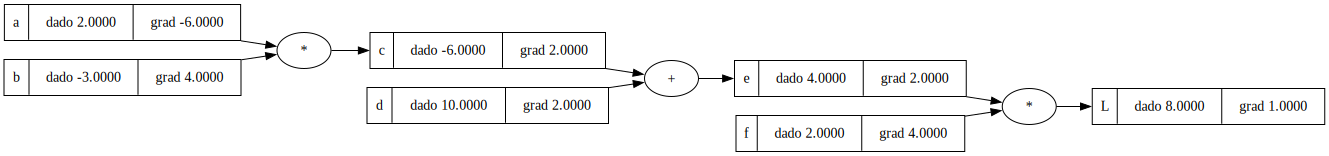

In [27]:
desenhe_grafo(L)

In [22]:
L.retropropag()

### Corrigindo um Erro Sutíl

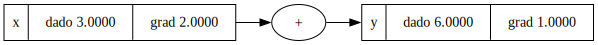

In [ ]:
x = Valor(3.0, rotulo='x')

y = x + x
y.rotulo = 'y'

y.retropropag()

desenhe_grafo(y)